# Optimal Skills: What are the most optimal skills to learn for Data Analysts?

## Import Libraries and Data

In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Loading Dataset
df = pd.read_csv(r'C:\Users\ARJUN\Python_projects\Python_Course\data_jobs.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

## Filter for US Data Analysts

In [2]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].dropna(subset = ['salary_year_avg']).copy()

## Explode the skills column

In [3]:
df_DA_US_exploded = df_DA_US.explode('job_skills')

## Skill frequency and median salary

In [4]:
df_DA_US_pivot = df_DA_US_exploded.pivot_table(index = 'job_skills', values = 'salary_year_avg', aggfunc = ['count','median']).sort_values(by = ('count','salary_year_avg'), ascending = False)
df_DA_US_pivot.columns = ['Skill_Cnt','Median_Salary']
df_DA_US_pivot['Skill_Percent'] = 100 * (df_DA_US_pivot['Skill_Cnt'] / len(df_DA_US))
df_DA_US_pivot

,Skill_Cnt,Median_Salary,Skill_Percent
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356
...,...,...,...
couchbase,1,160515.0,0.022989
chainer,1,100000.0,0.022989
chef,1,85000.0,0.022989


## Filter skills with demand above the defined percentage threshold

In [5]:
skill_limit = 5
df_DA_US_pivot_high_demand_skills = df_DA_US_pivot[df_DA_US_pivot['Skill_Percent'] > skill_limit]
df_DA_US_pivot_high_demand_skills

,Skill_Cnt,Median_Salary,Skill_Percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


## Clean Data

In [6]:
# Clean, organize, and expand technology skills into a structured DataFrame
df_technology = df['job_type_skills'].copy()

# Remove Duplicates
df_technology = df_technology.drop_duplicates().dropna()

# Define an empty dictionary
technology_dict = {}

for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value # if key already exists in technology_dict, add value
        else:
            technology_dict[key] = value # if key does not exist in technology_dict, add key and value
            
# Remove duplicates by converting to set and back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))
    
# Convert to DataFrame and explode the skills
df_technology = pd.DataFrame(technology_dict.items(), columns = ['Technology', 'Skills'])
df_technology = df_technology.explode('Skills')
df_technology

,Technology,Skills
0,analyst_tools,visio
0,analyst_tools,cognos
0,analyst_tools,nuix
0,analyst_tools,ms access
0,analyst_tools,sas
...,...,...
9,sync,ringcentral
9,sync,mattermost
9,sync,symphony
9,sync,microsoft teams


## Merge skills with their corresponding technology category

In [7]:
df_plot = df_DA_US_pivot_high_demand_skills.merge(df_technology, left_on = df_DA_US_pivot_high_demand_skills.index, right_on = 'Skills', how = 'inner').set_index('Skills')
df_plot

,Skill_Cnt,Median_Salary,Skill_Percent,Technology
Skills,,,,
sql,2508,91000.00,57.655172,programming
excel,1808,84392.00,41.563218,analyst_tools
python,1431,97500.00,32.896552,programming
tableau,1364,92875.00,31.356322,analyst_tools
sas,926,90000.00,21.287356,analyst_tools
sas,926,90000.00,21.287356,programming
r,893,92500.00,20.528736,programming
power bi,838,90000.00,19.264368,analyst_tools
powerpoint,462,85000.00,10.620690,analyst_tools


## Plot Scatterplot

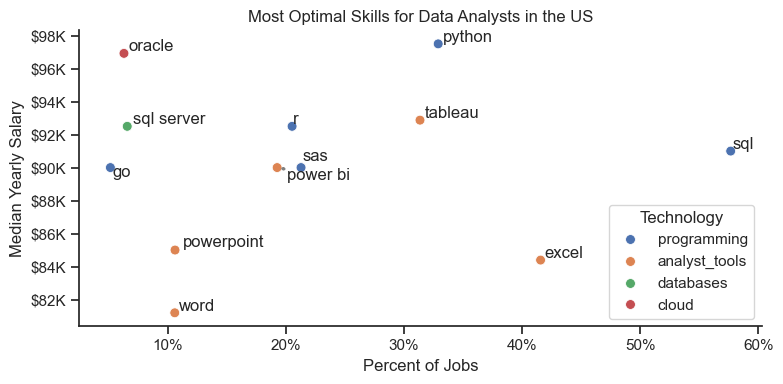

In [8]:
from adjustText import adjust_text

plt.figure(figsize = (8,4))

# df_DA_US_pivot_high_demand_skills.plot(kind = 'scatter', x = 'Skill_Percent', y = 'Median_Salary')

sns.set_theme(style = 'ticks')

sns.scatterplot(data = df_plot, x = 'Skill_Percent', y = 'Median_Salary', hue = 'Technology', s = 50)
sns.despine()
plt.title('Most Optimal Skills for Data Analysts in the US')
plt.xlabel('Percent of Jobs')
plt.ylabel('Median Yearly Salary')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000)}K'))

texts = []
for i, txt in enumerate(df_DA_US_pivot_high_demand_skills.index):
    texts.append(plt.text(df_DA_US_pivot_high_demand_skills['Skill_Percent'].iloc[i], df_DA_US_pivot_high_demand_skills['Median_Salary'].iloc[i], txt))

adjust_text(texts, arrowprops = dict(arrowstyle = '->', lw = 2, color = 'gray'))
plt.tight_layout()
plt.show()